# Часть 1. Прогнозирование рейтинга фильма (табличные данные, FCNN)

**Бизнес-задача** Хотим прогнозировать зрительский рейтинг по его характеристикам. Это позволит нам определять, какой контент продвигать на главной странице

Данные: https://www.kaggle.com/datasets/willianoliveiragibin/10000-data-about-movies-1915-2023?select=data.csv

Content:
- movie_name: The title of the movie.
- year: The year of the movie's release.
- rating: IMDb user rating.
- metascore: Metascore rating.
- gross_income: Gross income of the movie.
- votes: Number of votes on IMDb.
- runtime: Duration of the movie in minutes.
- genre: Genre(s) of the movie.
- certificate: Certification or rating of the movie.
- description: A brief summary or plot of the movie.
- directors: Director(s) of the movie.
- stars: Main cast or actors of the movie.



In [1]:
import wandb
#wandb.login()

/opt/anaconda3/lib/python3.12/site-packages/requests/__init__.py:113: RequestsDependencyWarning: urllib3 (2.6.3) or chardet (7.4.3)/charset_normalizer (2.0.4) doesn't match a supported version!
  warnings.warn(


In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

### Загрузка данных

In [3]:
df = pd.read_csv('data.csv', index_col=0)


In [4]:
df.dtypes

Movie Name              object
Year of Release          int64
Run Time in minutes      int64
Movie Rating           float64
Votes                    int64
MetaScore              float64
Gross                  float64
Genre                   object
Certification           object
Director                object
Stars                   object
Description             object
dtype: object

In [5]:
df

,Movie Name,Year of Release,Run Time in minutes,Movie Rating,Votes,MetaScore,Gross,Genre,Certification,Director,Stars,Description
0,The Shawshank Redemption,1994,142,9.3,2804443,82.0,28340000.0,['Drama'],R,['Frank Darabont'],"['Tim Robbins', 'Morgan Freeman', 'Bob Gunton'...","['Over', 'the', 'course', 'of', 'several', 'ye..."
1,The Godfather,1972,175,9.2,1954174,100.0,134970000.0,"['Crime', ' Drama']",R,['Francis Ford Coppola'],"['Marlon Brando', 'Al Pacino', 'James Caan', '...","['Don', 'Vito', 'Corleone,', 'head', 'of', 'a'..."
2,Ramayana: The Legend of Prince Rama,1993,135,9.2,12995,NaN,NaN,"['Animation', ' Action', ' Adventure']",PG,"['Ram Mohan', 'Yûgô Sakô', 'Koichi Saski']","['Arun Govil', 'Nikhil Kapoor', 'Edie Mirman',...","['An', 'anime', 'adaptation', 'of', 'the', 'Hi..."
3,The Chaos Class,1975,87,9.2,42231,NaN,NaN,"['Comedy', ' Drama']",NaN,['Ertem Egilmez'],"['Kemal Sunal', 'Münir Özkul', 'Halit Akçatepe...","['Lazy,', 'uneducated', 'students', 'share', '..."
4,The Dark Knight,2008,152,9.0,2786129,84.0,534860000.0,"['Action', ' Crime', ' Drama']",PG-13,['Christopher Nolan'],"['Christian Bale', 'Heath Ledger', 'Aaron Eckh...","['When', 'the', 'menace', 'known', 'as', 'the'..."
...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Golmaal Again,2017,140,4.9,10183,NaN,1010000.0,"['Action', ' Comedy', ' Fantasy']",Not Rated,['Rohit Shetty'],"['Ajay Devgn', 'Arshad Warsi', 'Tabu', 'Shreya...","['The', 'gang', 'encounters', 'with', 'some', ..."
9996,Not to Forget,2021,84,4.9,11191,NaN,NaN,['Drama'],NaN,['Valerio Zanoli'],"['Karen Grassle', 'Louis Gossett Jr.', ""Tatum ...","['After', 'a', 'lifetime', 'of', 'scams,', 'a'..."
9997,Housefull 3,2016,140,4.9,10308,NaN,1160000.0,"['Action', ' Comedy', ' Romance']",Not Rated,"['Sajid', 'Farhad Samji']","['Akshay Kumar', 'Abhishek Bachchan', 'Riteish...","['A', 'father', ""doesn't"", 'want', 'his', 'thr..."
9998,A.I. Rising,2018,85,4.9,11187,NaN,NaN,"['Drama', ' Romance', ' Sci-Fi']",R,['Lazar Bodroza'],"['Sebastian Cavazza', 'Stoya', 'Marusa Majer',...","['An', 'intimate', 'relationship', 'between', ..."


### Пропуски

In [6]:
df.isnull().sum()

Movie Name                0
Year of Release           0
Run Time in minutes       0
Movie Rating              0
Votes                     0
MetaScore              2026
Gross                  2915
Genre                     0
Certification           369
Director                  0
Stars                     0
Description               0
dtype: int64

Есть пропуски в доходах, метарейтинге, возрастном жанре

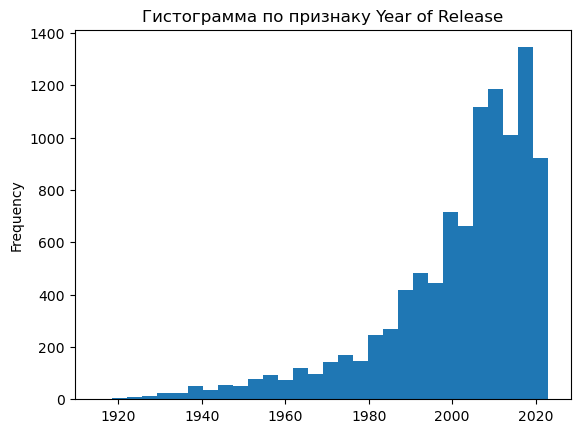

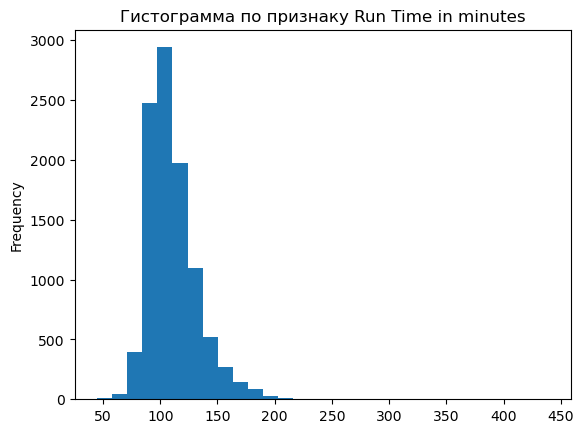

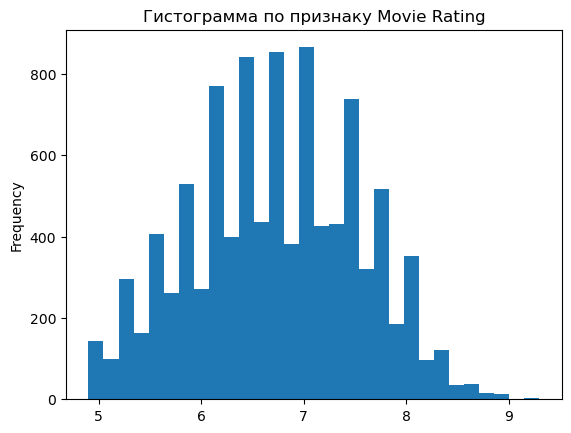

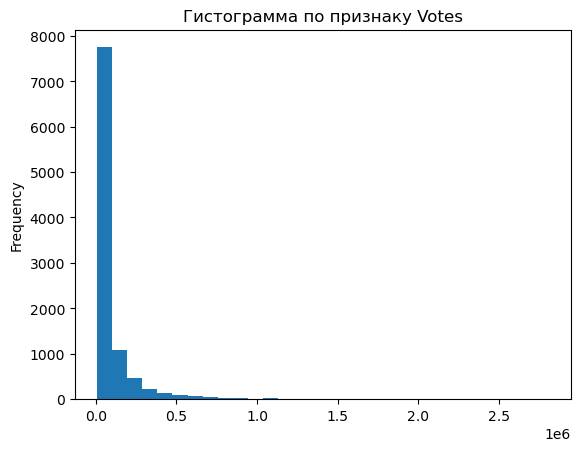

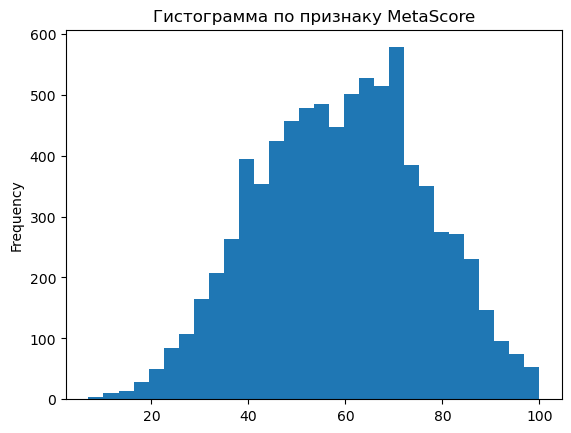

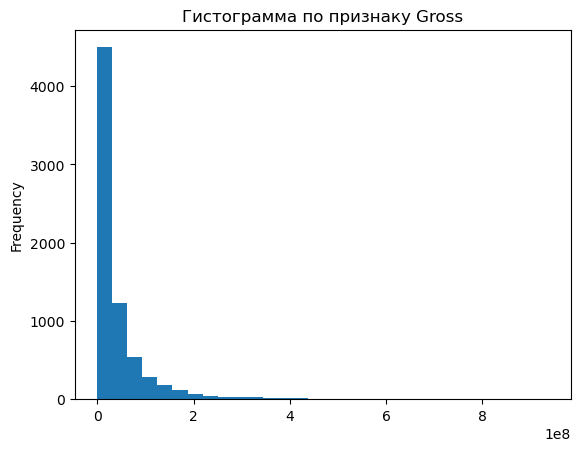

In [7]:
for i in df.columns:
    if df[i].dtype in ['int64', 'float64']:
        plt.figure()
        df[i].plot(kind='hist', title=f'Гистограмма по признаку {i}', bins=30)

Имеется сильная ассиметрия у рпризнаков votes и gross в правом хвосте. Логарифмируем и смотрим что произойдет. Заодно посмотрим что случится с другими фичами

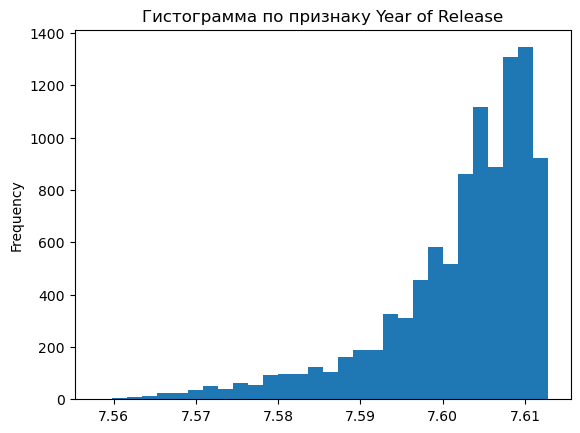

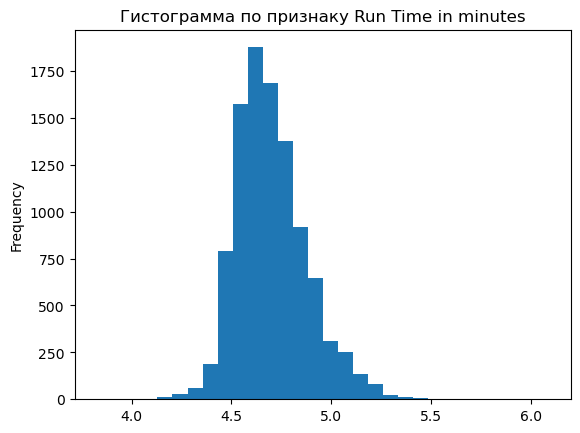

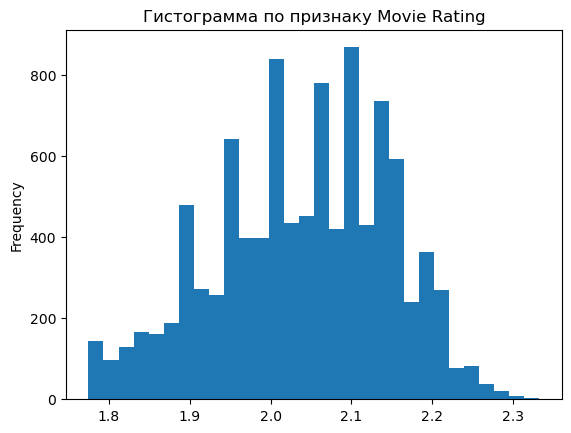

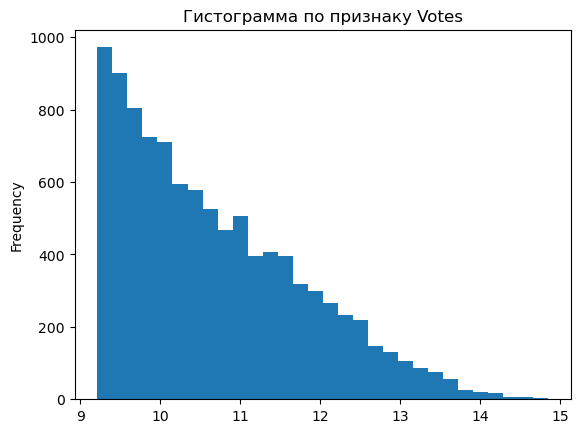

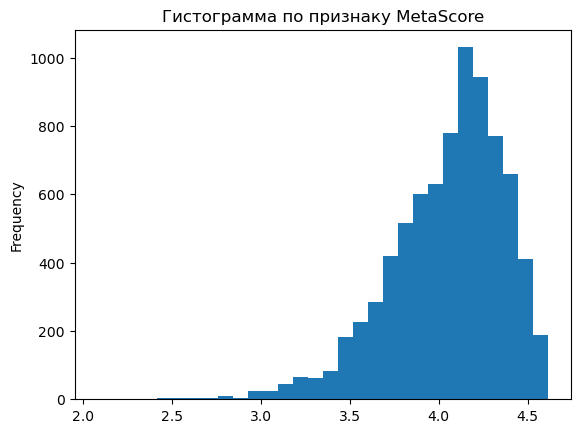

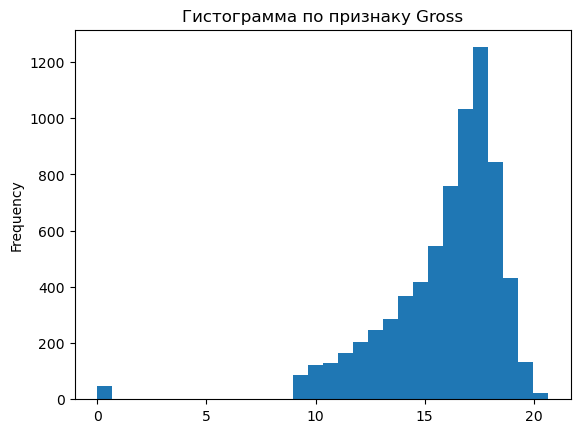

In [8]:
for i in df.columns:
    if df[i].dtype in ['int64', 'float64']:
        plt.figure()
        np.log1p(df[i]).plot(kind='hist', title=f'Гистограмма по признаку {i}', bins=30)

### создание новых признаков


In [9]:
split_col = lambda col: col.str.strip("[]").str.split(",").map(lambda lst: [x.strip(" '\"") for x in lst]) #1)скобки, 2)сплит по запятой 3) у каждого срезаем пробелы и кавычки

stars, dirs = split_col(df.Stars), split_col(df.Director)

top_actors = stars.explode().value_counts().head(20).index
top_directors = dirs.explode().value_counts().head(20).index

df = df.assign(
    log_votes=np.log1p(df.Votes),
    log_gross=np.log1p(df.Gross),
    genres_list=split_col(df.Genre),
    count_top_actors=stars.map(lambda s: sum(a in top_actors for a in s)),
    count_top_dirs=dirs.map(lambda s: sum(d in top_directors for d in s)),
    metascore_missing=df.MetaScore.isna().astype(int),
    gross_missing=df.Gross.isna().astype(int),      
).assign(
    main_genre=lambda d: d.genres_list.str[0],        #первый в списке жанр будет главным
    count_genres=lambda d: d.genres_list.map(len),# колво жанров
    has_top_actor=lambda d: (d.count_top_actors > 0).astype(int), #бинарный
    has_top_dir=lambda d: (d.count_top_dirs > 0).astype(int), #бин
)
df

,Movie Name,Year of Release,Run Time in minutes,Movie Rating,Votes,MetaScore,Gross,Genre,Certification,Director,...,log_gross,genres_list,count_top_actors,count_top_dirs,metascore_missing,gross_missing,main_genre,count_genres,has_top_actor,has_top_dir
0,The Shawshank Redemption,1994,142,9.3,2804443,82.0,28340000.0,['Drama'],R,['Frank Darabont'],...,17.159785,[Drama],1,0,0,0,Drama,1,1,0
1,The Godfather,1972,175,9.2,1954174,100.0,134970000.0,"['Crime', ' Drama']",R,['Francis Ford Coppola'],...,18.720563,"[Crime, Drama]",0,0,0,0,Crime,2,0,0
2,Ramayana: The Legend of Prince Rama,1993,135,9.2,12995,NaN,NaN,"['Animation', ' Action', ' Adventure']",PG,"['Ram Mohan', 'Yûgô Sakô', 'Koichi Saski']",...,NaN,"[Animation, Action, Adventure]",0,0,1,1,Animation,3,0,0
3,The Chaos Class,1975,87,9.2,42231,NaN,NaN,"['Comedy', ' Drama']",NaN,['Ertem Egilmez'],...,NaN,"[Comedy, Drama]",0,0,1,1,Comedy,2,0,0
4,The Dark Knight,2008,152,9.0,2786129,84.0,534860000.0,"['Action', ' Crime', ' Drama']",PG-13,['Christopher Nolan'],...,20.097516,"[Action, Crime, Drama]",1,0,0,0,Action,3,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Golmaal Again,2017,140,4.9,10183,NaN,1010000.0,"['Action', ' Comedy', ' Fantasy']",Not Rated,['Rohit Shetty'],...,13.825462,"[Action, Comedy, Fantasy]",0,0,1,0,Action,3,0,0
9996,Not to Forget,2021,84,4.9,11191,NaN,NaN,['Drama'],NaN,['Valerio Zanoli'],...,NaN,[Drama],0,0,1,1,Drama,1,0,0
9997,Housefull 3,2016,140,4.9,10308,NaN,1160000.0,"['Action', ' Comedy', ' Romance']",Not Rated,"['Sajid', 'Farhad Samji']",...,13.963931,"[Action, Comedy, Romance]",1,0,1,0,Action,3,1,0
9998,A.I. Rising,2018,85,4.9,11187,NaN,NaN,"['Drama', ' Romance', ' Sci-Fi']",R,['Lazar Bodroza'],...,NaN,"[Drama, Romance, Sci-Fi]",0,0,1,1,Drama,3,0,0


### гистограмма и боксплот рейтинга

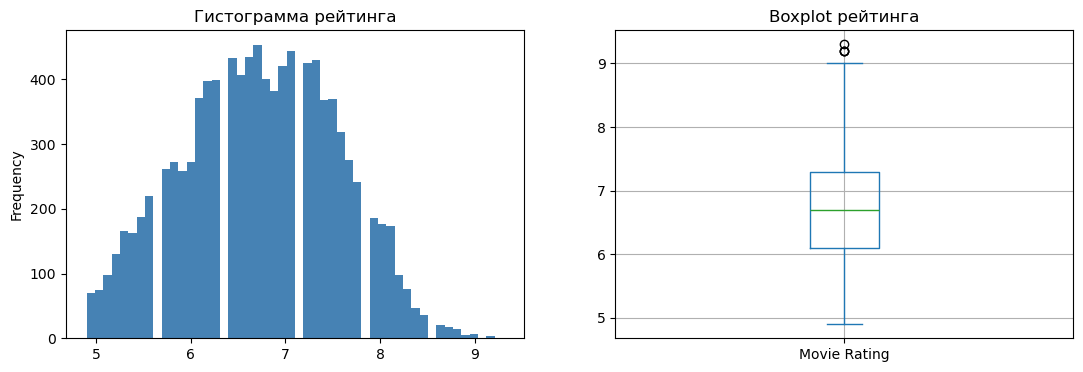

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

df['Movie Rating'].plot(kind='hist', bins=50, ax=axes[0], color='steelblue',title='Гистограмма рейтинга')
df['Movie Rating'].plot(kind='box', ax=axes[1], title='Boxplot рейтинга', grid=1)

plt.show()

### фильмы и рейтинг по годам выпуска

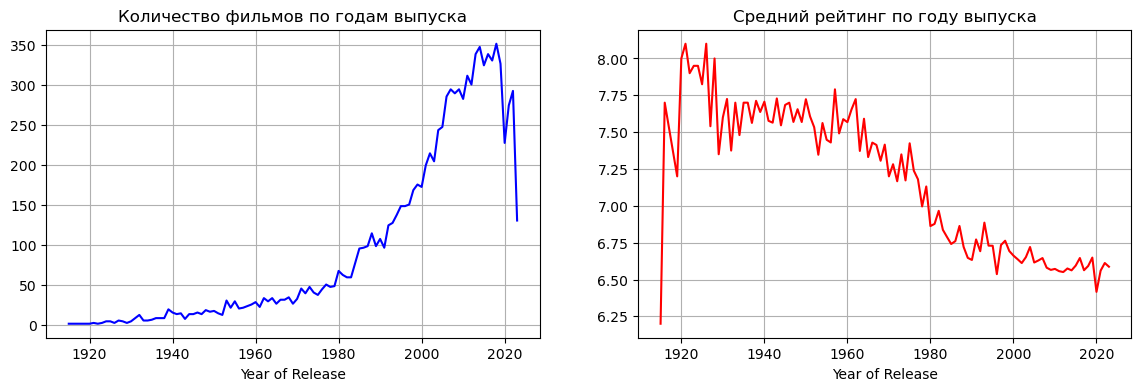

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby('Year of Release').size().plot(ax=axes[0], color='blue', title='Количество фильмов по годам выпуска',grid=1)
df.groupby('Year of Release')['Movie Rating'].mean().plot(ax=axes[1], color='red', title='Средний рейтинг по году выпуска',grid=1)

plt.show()

### гистограммы числовыъ признаков

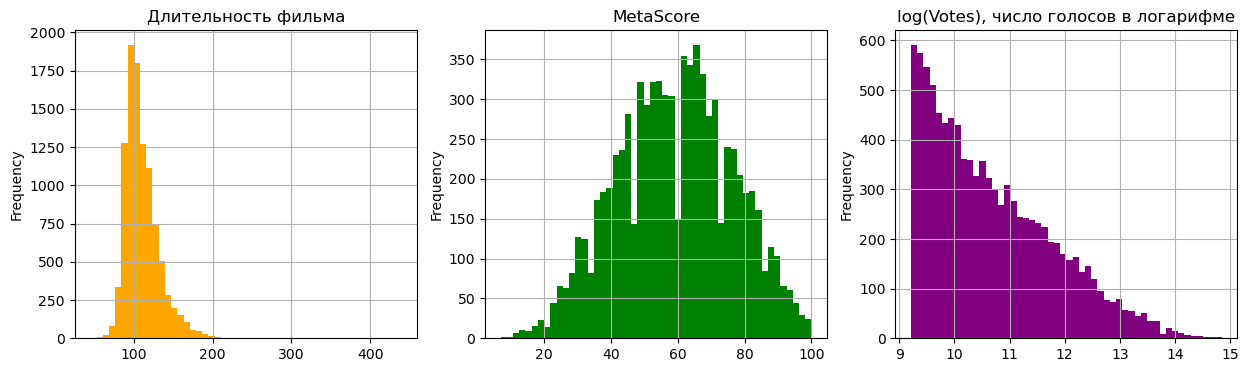

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

df['Run Time in minutes'].plot(kind='hist', bins=50, ax=axes[0], color='orange',title='Длительность фильма',grid=1)
df['MetaScore'].plot(kind='hist', bins=50, ax=axes[1], color='green',title='MetaScore',grid=1)
df['log_votes'].plot(kind='hist', bins=50, ax=axes[2], color='purple',title='log(Votes), число голосов в логарифме',grid=1)

plt.show()

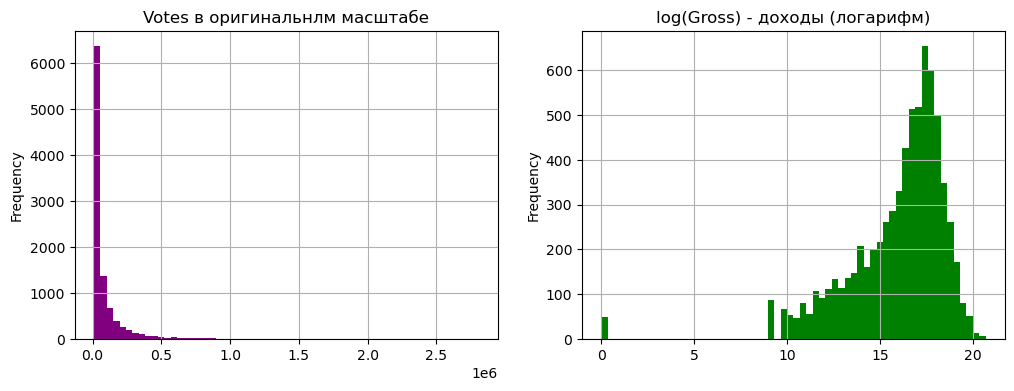

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

df['Votes'].plot(kind='hist', bins=60, ax=axes[0], color='purple',title='Votes в оригинальнлм масштабе',grid=1)
df['log_gross'].plot(kind='hist', bins=60, ax=axes[1], color='green',title='log(Gross) - доходы (логарифм)',grid=1)

plt.show()

### 2.4 Корреляционный анализ

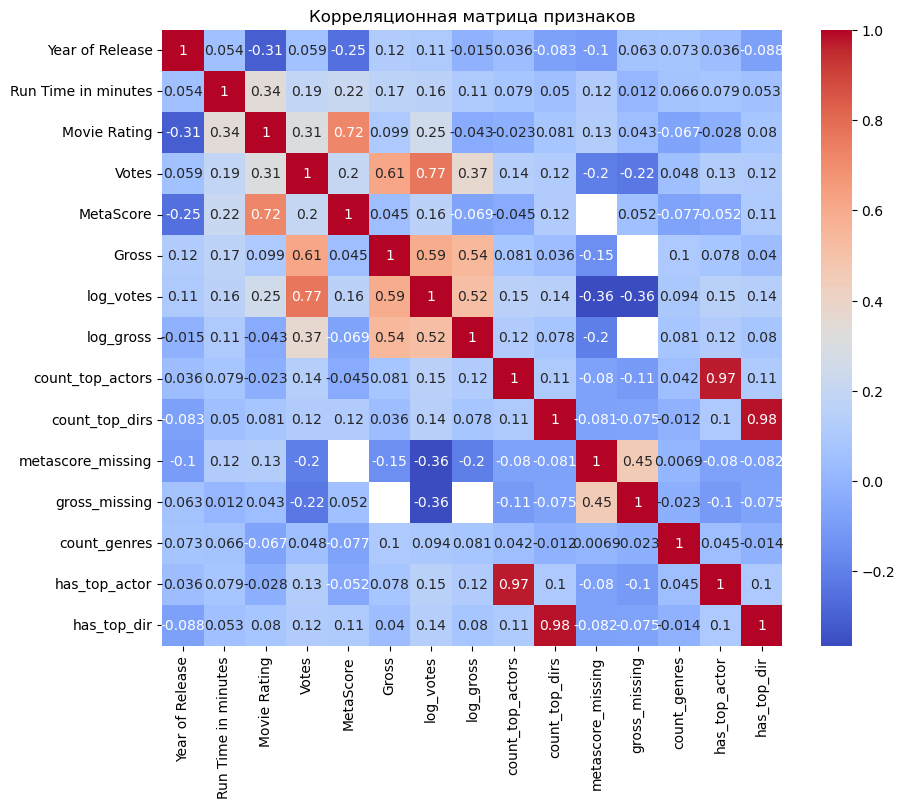

In [14]:

corr = df.corr(numeric_only=1)

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Корреляционная матрица признаков')
plt.show()

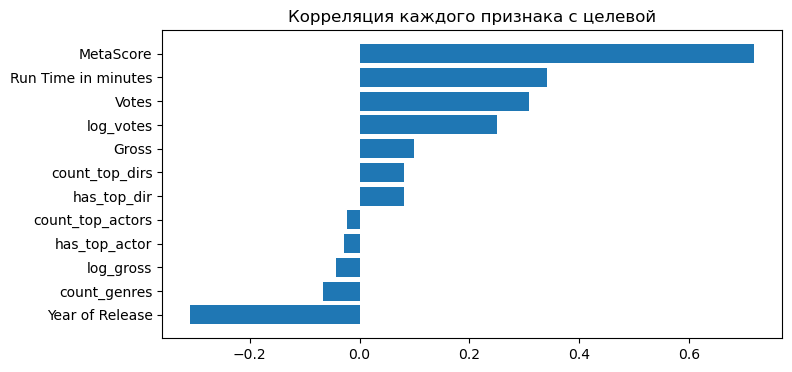

In [15]:
num_cols_corr = ['Year of Release', 'Run Time in minutes', 'MetaScore', 'Votes', 'Gross', 'Movie Rating', 'log_votes', 'log_gross', 'count_top_actors',
'count_top_dirs', 'count_genres', 'has_top_actor', 'has_top_dir']

target_corr = df[num_cols_corr].corr()['Movie Rating'].drop('Movie Rating').sort_values()

plt.figure(figsize=(8, 4))
plt.barh(target_corr.index, target_corr.values)
plt.title('Корреляция каждого признака с целевой')
plt.show()


### зрительский рейтинг по возрастному рейтингу

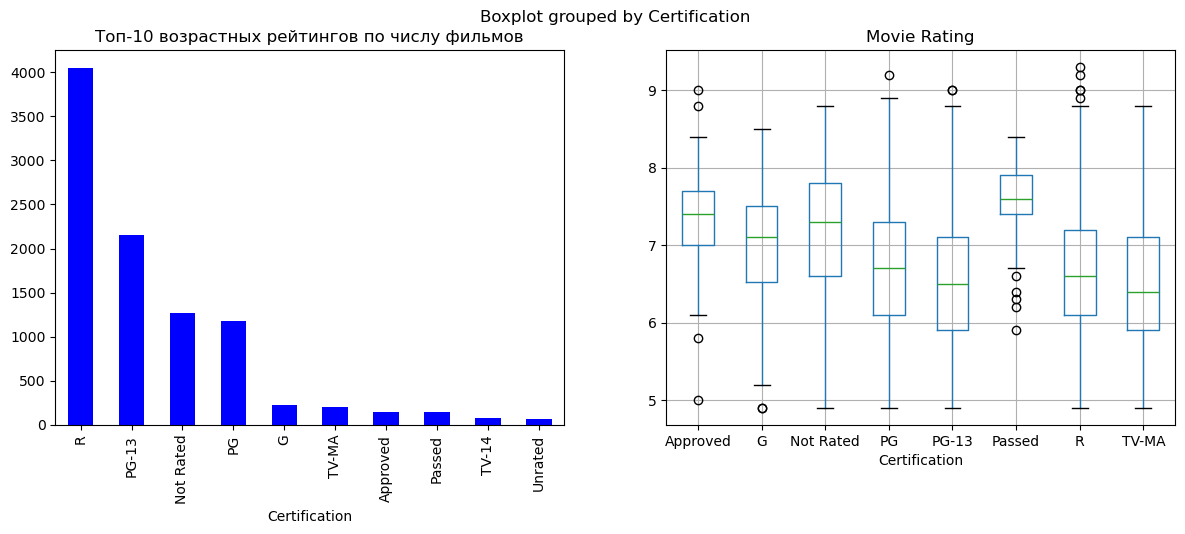

In [16]:
top_certs = df.Certification.value_counts().head(8).index
cert_data = df[df.Certification.isin(top_certs)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

df.Certification.value_counts().head(10).plot(kind='bar', ax=axes[0], color='blue',title='Топ-10 возрастных рейтингов по числу фильмов')

cert_data.boxplot(column='Movie Rating', by='Certification', ax=axes[1])
plt.show()

### связь числовых признаков с рейтингом

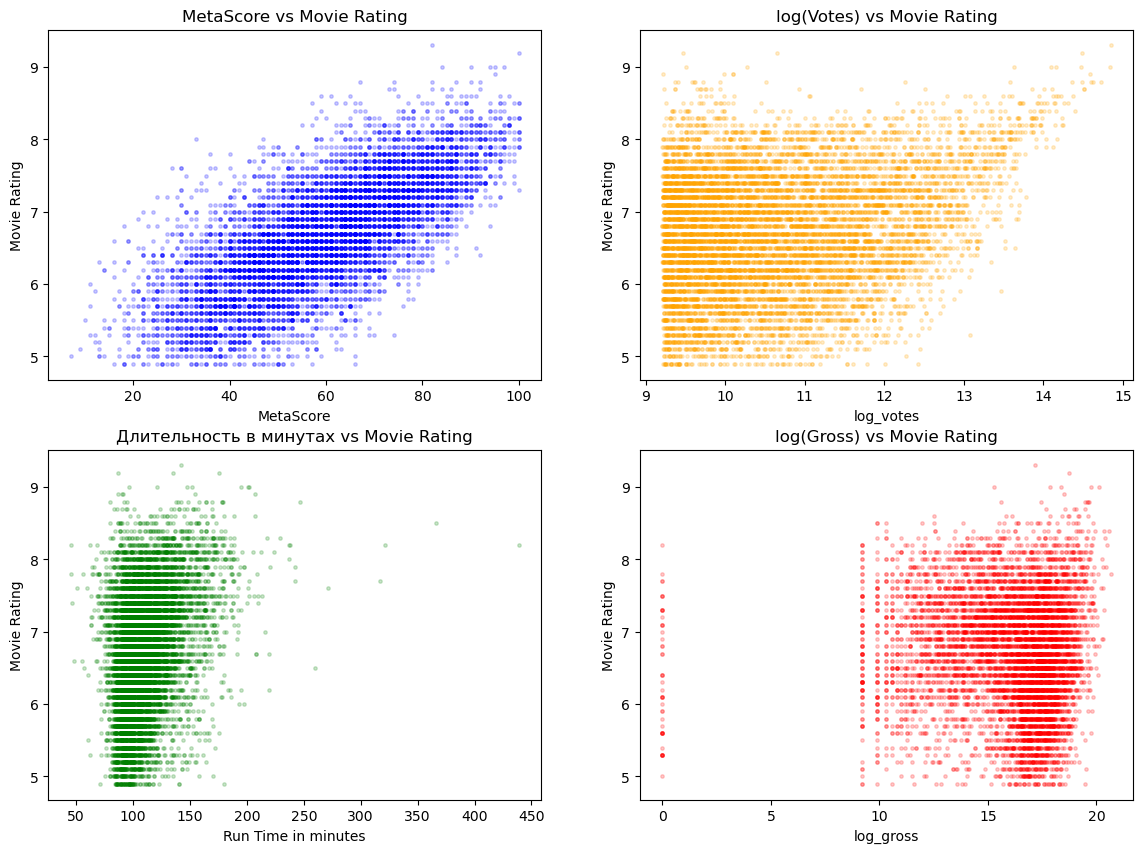

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

df.plot(kind='scatter', x='MetaScore', y='Movie Rating', alpha=0.2, s=6,ax=axes[0, 0], color='blue', title='MetaScore vs Movie Rating')
df.plot(kind='scatter', x='log_votes', y='Movie Rating', alpha=0.2, s=6,ax=axes[0, 1], color='orange', title='log(Votes) vs Movie Rating')
df.plot(kind='scatter', x='Run Time in minutes', y='Movie Rating', alpha=0.2, s=6,ax=axes[1, 0], color='green', title='Длительность в минутах vs Movie Rating')
df.plot(kind='scatter', x='log_gross', y='Movie Rating', alpha=0.2, s=6,ax=axes[1, 1], color='red', title='log(Gross) vs Movie Rating')

plt.show()

In [18]:
df

,Movie Name,Year of Release,Run Time in minutes,Movie Rating,Votes,MetaScore,Gross,Genre,Certification,Director,...,log_gross,genres_list,count_top_actors,count_top_dirs,metascore_missing,gross_missing,main_genre,count_genres,has_top_actor,has_top_dir
0,The Shawshank Redemption,1994,142,9.3,2804443,82.0,28340000.0,['Drama'],R,['Frank Darabont'],...,17.159785,[Drama],1,0,0,0,Drama,1,1,0
1,The Godfather,1972,175,9.2,1954174,100.0,134970000.0,"['Crime', ' Drama']",R,['Francis Ford Coppola'],...,18.720563,"[Crime, Drama]",0,0,0,0,Crime,2,0,0
2,Ramayana: The Legend of Prince Rama,1993,135,9.2,12995,NaN,NaN,"['Animation', ' Action', ' Adventure']",PG,"['Ram Mohan', 'Yûgô Sakô', 'Koichi Saski']",...,NaN,"[Animation, Action, Adventure]",0,0,1,1,Animation,3,0,0
3,The Chaos Class,1975,87,9.2,42231,NaN,NaN,"['Comedy', ' Drama']",NaN,['Ertem Egilmez'],...,NaN,"[Comedy, Drama]",0,0,1,1,Comedy,2,0,0
4,The Dark Knight,2008,152,9.0,2786129,84.0,534860000.0,"['Action', ' Crime', ' Drama']",PG-13,['Christopher Nolan'],...,20.097516,"[Action, Crime, Drama]",1,0,0,0,Action,3,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,Golmaal Again,2017,140,4.9,10183,NaN,1010000.0,"['Action', ' Comedy', ' Fantasy']",Not Rated,['Rohit Shetty'],...,13.825462,"[Action, Comedy, Fantasy]",0,0,1,0,Action,3,0,0
9996,Not to Forget,2021,84,4.9,11191,NaN,NaN,['Drama'],NaN,['Valerio Zanoli'],...,NaN,[Drama],0,0,1,1,Drama,1,0,0
9997,Housefull 3,2016,140,4.9,10308,NaN,1160000.0,"['Action', ' Comedy', ' Romance']",Not Rated,"['Sajid', 'Farhad Samji']",...,13.963931,"[Action, Comedy, Romance]",1,0,1,0,Action,3,1,0
9998,A.I. Rising,2018,85,4.9,11187,NaN,NaN,"['Drama', ' Romance', ' Sci-Fi']",R,['Lazar Bodroza'],...,NaN,"[Drama, Romance, Sci-Fi]",0,0,1,1,Drama,3,0,0


In [19]:
data = df.assign(
    metascore=df.MetaScore.fillna(df.MetaScore.median()),
    log_gross=df.log_gross.fillna(df.log_gross.median()),
    cert=df.Certification.fillna('Unknown'),
    rating=df['Movie Rating'].astype(np.float32),
)

genre_dummies = pd.get_dummies(data.main_genre, prefix='genre')
cert_dummies  = pd.get_dummies(data.cert, prefix='cert')


num_cols = ['Year of Release', 'Run Time in minutes', 'log_votes', 'log_gross', 'metascore', 'count_top_actors', 'count_top_dirs', 'count_genres']
bin_cols = ['has_top_actor', 'has_top_dir', 'metascore_missing', 'gross_missing']
X = pd.concat([data[num_cols], data[bin_cols], genre_dummies, cert_dummies], axis=1).astype(np.float32)
y = data.rating


In [20]:
X

,Year of Release,Run Time in minutes,log_votes,log_gross,metascore,count_top_actors,count_top_dirs,count_genres,has_top_actor,has_top_dir,...,cert_TV-13,cert_TV-14,cert_TV-G,cert_TV-MA,cert_TV-PG,cert_TV-Y7,cert_TV-Y7-FV,cert_Unknown,cert_Unrated,cert_X
0,1994.0,142.0,14.846716,17.159784,82.0,1.0,0.0,1.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,1972.0,175.0,14.485478,18.720564,100.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,1993.0,135.0,9.472397,16.644598,60.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,1975.0,87.0,10.650933,16.644598,60.0,0.0,0.0,2.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
4,2008.0,152.0,14.840164,20.097515,84.0,1.0,0.0,3.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,2017.0,140.0,9.228573,13.825462,60.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9996,2021.0,84.0,9.322954,16.644598,60.0,0.0,0.0,1.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0
9997,2016.0,140.0,9.240772,13.963931,60.0,1.0,0.0,3.0,1.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
9998,2018.0,85.0,9.322598,16.644598,60.0,0.0,0.0,3.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
